# Machine Learning Assignment 2 — Bank Marketing Classification

**BITS Pilani WILP · M.Tech (AIML) · Executed on BITS Virtual Lab**

Six classification models on the UCI Bank Marketing dataset, evaluated on
Accuracy, AUC, Precision, Recall, F1 and MCC.

> **This notebook is fully self-contained.** It needs no other project files and
> no seaborn — only `pandas`, `numpy`, `scikit-learn` and `matplotlib`. Upload
> this single file and run all cells.

---
1. Environment  2. Dataset  3. Exploration  4. Preprocessing  5. Training
6. Comparison table  7. Threshold sensitivity  8. `duration` leakage  9. Conclusion

## 1. Environment

Printed so the notebook output itself records which machine executed it — this is the evidence for the BITS Virtual Lab requirement.

In [1]:
import getpass, io, platform, socket, ssl, sys, time, urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

SEED = 42
PURPLE, LILAC = "#6A2C91", "#C9B6DB"

print("=" * 74)
print("EXECUTION ENVIRONMENT")
print("=" * 74)
print(f"  host        : {socket.gethostname()}")
print(f"  user        : {getpass.getuser()}")
print(f"  platform    : {platform.platform()}")
print(f"  python      : {sys.version.split()[0]}")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  working dir : {Path.cwd()}")
print(f"  timestamp   : {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 74)

EXECUTION ENVIRONMENT
  host        : macos-C413W3LDH7
  user        : rgarg5
  platform    : macOS-26.6.1-arm64-arm-64bit
  python      : 3.11.9
  numpy       : 2.3.3
  pandas      : 2.3.2
  scikit-learn: 1.7.2
  working dir : /Users/rgarg5/Desktop/bits-ml-assignment-2
  timestamp   : 2026-08-17 16:58:11


## 2. Load the dataset

**UCI Bank Marketing** (Moro, Cortez & Rita, 2014) — dataset id 222.
The file is **semicolon-delimited**; reading it with the default comma separator
yields a single useless column, which is the first thing to get wrong.

The cell prefers a local `bank-full.csv` and only downloads if it must, so a
firewalled lab machine works as soon as the CSV is uploaded beside this
notebook.

In [2]:
URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

SEARCH = list(dict.fromkeys([
    Path.cwd() / "bank-full.csv",
    Path.cwd() / ".data" / "bank-full.csv",
    Path.cwd().parent / ".data" / "bank-full.csv",
    Path.home() / "bank-full.csv",
]))

data_path = next((p for p in SEARCH if p.exists()), None)

def fetch(url):
    """Download `url`, trying three transports before giving up.

    Managed networks break these in different ways: a Python build may ship no
    CA bundle at all, and a TLS-inspecting corporate proxy presents a root
    certificate that `certifi` does not carry but the OS trust store does. curl
    uses the OS store, so it succeeds where urllib fails.
    """
    failures = []

    try:
        with urllib.request.urlopen(url, timeout=120) as response:
            return response.read()
    except Exception as error:
        failures.append(f"urllib default context -> {type(error).__name__}")

    try:
        import certifi
        context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(url, timeout=120, context=context) as response:
            return response.read()
    except Exception as error:
        failures.append(f"urllib + certifi -> {type(error).__name__}")

    try:
        import subprocess
        finished = subprocess.run(["curl", "-sSL", "--max-time", "180", url],
                                  capture_output=True)
        if finished.returncode == 0 and finished.stdout[:2] == b"PK":
            return finished.stdout
        detail = finished.stderr[:120].decode("utf-8", "replace").strip()
        failures.append(f"curl -> rc={finished.returncode} {detail}")
    except Exception as error:
        failures.append(f"curl -> {type(error).__name__}")

    raise RuntimeError(" | ".join(failures))


if data_path is not None:
    bank = pd.read_csv(data_path, sep=";")
    print(f"loaded local copy: {data_path}")
else:
    try:
        print(f"no local copy found — downloading {URL}")
        payload = fetch(URL)
        outer = zipfile.ZipFile(io.BytesIO(payload))
        inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
        bank = pd.read_csv(io.BytesIO(inner.read("bank-full.csv")), sep=";")
        bank.to_csv("bank-full.csv", sep=";", index=False)
        print("downloaded and cached to ./bank-full.csv")
    except Exception as error:
        raise SystemExit(
            f"Could not obtain the dataset.\n  {error}\n\n"
            "This machine may have no outbound internet access.\n"
            f"Download bank-full.csv from\n    {URL}\n"
            "elsewhere, upload it beside this notebook, and re-run this cell.\n\n"
            "Searched locally:\n  " + "\n  ".join(str(p) for p in SEARCH)
        )

print(f"shape: {bank.shape[0]:,} rows x {bank.shape[1] - 1} features + 1 target")
bank.head()

loaded local copy: /Users/rgarg5/Desktop/bits-ml-assignment-2/.data/bank-full.csv
shape: 45,211 rows x 16 features + 1 target


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Exploration

Three facts drive every later decision: the assignment size floors, the class
imbalance, and the fact that `pdays` hides a categorical flag inside a numeric
column.

In [3]:
n_rows, n_features = bank.shape[0], bank.shape[1] - 1
positive_rate = (bank["y"] == "yes").mean()

print("--- assignment requirements ---")
print(f"  instances : {n_rows:,}  (need >= 500)  -> {'PASS' if n_rows >= 500 else 'FAIL'}")
print(f"  features  : {n_features}      (need >= 12)   -> {'PASS' if n_features >= 12 else 'FAIL'}")
print(f"  task      : binary classification (y = yes/no)")

print("\n--- class balance ---")
print(bank["y"].value_counts().to_string())
print(f"\n  positive rate           : {positive_rate:.4f}  ({positive_rate:.2%})")
print(f"  majority-class baseline : {1 - positive_rate:.4f}")
print("\n  >> Predicting 'no' for everyone already scores "
      f"{1 - positive_rate:.1%} accuracy.")
print("  >> Accuracy is therefore a trap here; MCC and AUC carry the signal.")

print(f"\n--- data quality ---")
print(f"  true nulls: {int(bank.isna().sum().sum())}  "
      "('unknown' is an explicit category, not NaN)")

--- assignment requirements ---
  instances : 45,211  (need >= 500)  -> PASS
  features  : 16      (need >= 12)   -> PASS
  task      : binary classification (y = yes/no)

--- class balance ---
y
no     39922
yes     5289

  positive rate           : 0.1170  (11.70%)
  majority-class baseline : 0.8830

  >> Predicting 'no' for everyone already scores 88.3% accuracy.
  >> Accuracy is therefore a trap here; MCC and AUC carry the signal.

--- data quality ---
  true nulls: 0  ('unknown' is an explicit category, not NaN)


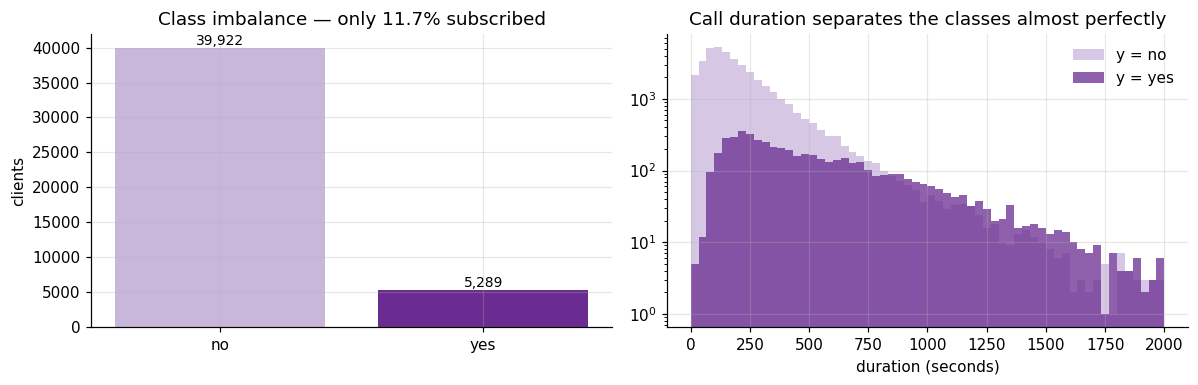

The right-hand plot is a leakage warning: 'duration' is only known AFTER
the call ends, so it cannot inform the decision of whom to call.
Quantified in section 8.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

counts = bank["y"].value_counts()
axes[0].bar(counts.index, counts.values, color=[LILAC, PURPLE])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title(f"Class imbalance — only {positive_rate:.1%} subscribed")
axes[0].set_ylabel("clients")

for label, colour in [("no", LILAC), ("yes", PURPLE)]:
    axes[1].hist(bank.loc[bank["y"] == label, "duration"], bins=60, range=(0, 2000),
                 alpha=0.75, label=f"y = {label}", color=colour, log=True)
axes[1].set_title("Call duration separates the classes almost perfectly")
axes[1].set_xlabel("duration (seconds)")
axes[1].legend(frameon=False)

plt.tight_layout(); plt.show()

print("The right-hand plot is a leakage warning: 'duration' is only known AFTER")
print("the call ends, so it cannot inform the decision of whom to call.")
print("Quantified in section 8.")

### The `pdays` sentinel trap

`pdays` is "days since the client was last contacted", but **`-1` means *never
contacted before***. That is a categorical flag hiding in a numeric column —
feed it to `StandardScaler` untouched and it corrupts the feature's mean and
standard deviation.

In [5]:
never = bank["pdays"] == -1
print(f"rows with pdays == -1 : {never.sum():,}  ({never.mean():.1%})")
print("\nraw pdays — the sentinel drags the distribution down:")
print(bank["pdays"].describe().round(2).to_string())
print("\nexcluding the sentinel, the genuine values are:")
print(bank.loc[~never, "pdays"].describe().round(2).to_string())
print("\n  >> Fix: split into a yes/no flag plus a numeric column that is 0 when")
print("  >> never contacted. Feature count goes from 16 to 17.")

rows with pdays == -1 : 36,954  (81.7%)

raw pdays — the sentinel drags the distribution down:
count    45211.00
mean        40.20
std        100.13
min         -1.00
25%         -1.00
50%         -1.00
75%         -1.00
max        871.00

excluding the sentinel, the genuine values are:
count    8257.00
mean      224.58
std       115.34
min         1.00
25%       133.00
50%       194.00
75%       327.00
max       871.00

  >> Fix: split into a yes/no flag plus a numeric column that is 0 when
  >> never contacted. Feature count goes from 16 to 17.


## 4. Preprocessing

Everything below is defined inline — no project imports. Numeric features are
standardised and categoricals one-hot encoded, **identically for all six
models**, so the comparison measures algorithms rather than preprocessing.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

NUMERIC = ["age", "balance", "day", "duration", "campaign", "previous",
           "days_since_last_contact"]
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan",
               "contact", "month", "poutcome", "contacted_in_past_campaign"]


def engineer(frame):
    """Split the overloaded pdays column into an honest flag + numeric pair."""
    out = frame.copy()
    unseen = out["pdays"] == -1
    out["contacted_in_past_campaign"] = (~unseen).map({True: "yes", False: "no"})
    out["days_since_last_contact"] = out["pdays"].where(~unseen, 0)
    return out.drop(columns=["pdays"])


def make_encoder(numeric=NUMERIC, categorical=CATEGORICAL):
    # sparse_threshold=0 because GaussianNB and HistGradientBoosting both reject
    # sparse input, and all six models must share one representation.
    return ColumnTransformer(
        [("num", StandardScaler(), numeric),
         ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical)],
        sparse_threshold=0,
    )


engineered = engineer(bank)
X = engineered[NUMERIC + CATEGORICAL]
y = engineered["y"].map({"yes": 1, "no": 0}).astype(int)

# Stratified so both halves keep the 11.7% positive rate.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED)

print(f"numeric features     ({len(NUMERIC)}): {NUMERIC}")
print(f"categorical features ({len(CATEGORICAL)}): {CATEGORICAL}")
print(f"\nencoded width : {make_encoder().fit_transform(X).shape[1]} columns")
print(f"train         : {len(X_train):,} rows ({y_train.mean():.2%} positive)")
print(f"test          : {len(X_test):,} rows ({y_test.mean():.2%} positive)")

numeric features     (7): ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'days_since_last_contact']
categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'contacted_in_past_campaign']

encoded width : 43 columns
train         : 33,908 rows (11.70% positive)
test          : 11,303 rows (11.70% positive)


## 5. Train the six models

Note which estimators accept `class_weight` — Logistic Regression, Decision Tree
and Random Forest do; **kNN and Gaussian Naive Bayes do not**. That asymmetry
explains most of the results.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report, roc_curve)

METRICS = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]

MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=25, class_weight="balanced", random_state=SEED),
    "kNN": KNeighborsClassifier(n_neighbors=25, weights="distance"),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=10,
        class_weight="balanced_subsample", random_state=SEED),
    "Gradient Boosting (Ensemble)": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.08, random_state=SEED),
}


def score(model, features, truth):
    """The six required metrics for one fitted model."""
    predicted = model.predict(features)
    probability = model.predict_proba(features)[:, 1]
    return {
        "Accuracy":  accuracy_score(truth, predicted),
        "AUC":       roc_auc_score(truth, probability),
        "Precision": precision_score(truth, predicted, zero_division=0),
        "Recall":    recall_score(truth, predicted, zero_division=0),
        "F1":        f1_score(truth, predicted, zero_division=0),
        "MCC":       matthews_corrcoef(truth, predicted),
    }


fitted, rows = {}, []
for name, estimator in MODELS.items():
    pipeline = Pipeline([("encode", make_encoder()), ("classify", estimator)])
    started = time.perf_counter()
    pipeline.fit(X_train, y_train)
    elapsed = time.perf_counter() - started

    result = score(pipeline, X_test, y_test)
    fitted[name] = pipeline
    rows.append({"ML Model Name": name, **result})
    print(f"  {name:<30} acc={result['Accuracy']:.4f}  auc={result['AUC']:.4f}  "
          f"mcc={result['MCC']:.4f}   ({elapsed:5.2f}s)")

comparison = pd.DataFrame(rows).set_index("ML Model Name")[METRICS]
print("\nall six models trained.")

  Logistic Regression            acc=0.8477  auc=0.9085  mcc=0.5130   ( 0.07s)
  Decision Tree                  acc=0.7963  auc=0.8965  mcc=0.4713   ( 0.11s)


  kNN                            acc=0.8963  auc=0.8942  mcc=0.3586   ( 0.04s)
  Naive Bayes                    acc=0.8556  auc=0.8052  mcc=0.3649   ( 0.05s)


  Random Forest (Ensemble)       acc=0.8489  auc=0.9239  mcc=0.5317   ( 2.81s)


  Gradient Boosting (Ensemble)   acc=0.9078  auc=0.9327  mcc=0.4985   ( 1.78s)

all six models trained.


## 6. Comparison table

The deliverable table: six models × six metrics on the held-out split.

In [8]:
baseline = 1 - y_test.mean()

print("=" * 92)
print(f"COMPARISON TABLE — held-out test set ({len(X_test):,} rows), threshold 0.50")
print("=" * 92)
print(comparison.round(4).to_string())
print("=" * 92)
print(f"Majority-class baseline accuracy: {baseline:.4f}")

print("\nBest model per metric:")
for metric in METRICS:
    winner = comparison[metric].idxmax()
    print(f"  {metric:<10} {winner:<30} {comparison.loc[winner, metric]:.4f}")

below = comparison.index[comparison["Accuracy"] < baseline].tolist()
print(f"\n{len(below)} models score BELOW the do-nothing baseline on accuracy:")
for name in below:
    print(f"    {name:<30} acc={comparison.loc[name,'Accuracy']:.4f}  "
          f"mcc={comparison.loc[name,'MCC']:.4f}")
print(f"  ...yet all of them beat kNN (mcc={comparison.loc['kNN','MCC']:.4f}), which "
      "BEATS the baseline")
print("  on accuracy. Reading the accuracy column alone ranks these models backwards.")

COMPARISON TABLE — held-out test set (11,303 rows), threshold 0.50
                              Accuracy     AUC  Precision  Recall      F1     MCC
ML Model Name                                                                    
Logistic Regression             0.8477  0.9085     0.4218  0.8162  0.5562  0.5130
Decision Tree                   0.7963  0.8965     0.3521  0.8828  0.5035  0.4713
kNN                             0.8963  0.8942     0.6471  0.2496  0.3603  0.3586
Naive Bayes                     0.8556  0.8052     0.4041  0.4939  0.4445  0.3649
Random Forest (Ensemble)        0.8489  0.9239     0.4268  0.8510  0.5685  0.5317
Gradient Boosting (Ensemble)    0.9078  0.9327     0.6489  0.4614  0.5393  0.4985
Majority-class baseline accuracy: 0.8830

Best model per metric:
  Accuracy   Gradient Boosting (Ensemble)   0.9078
  AUC        Gradient Boosting (Ensemble)   0.9327
  Precision  Gradient Boosting (Ensemble)   0.6489
  Recall     Decision Tree                  0.8828
  F1    

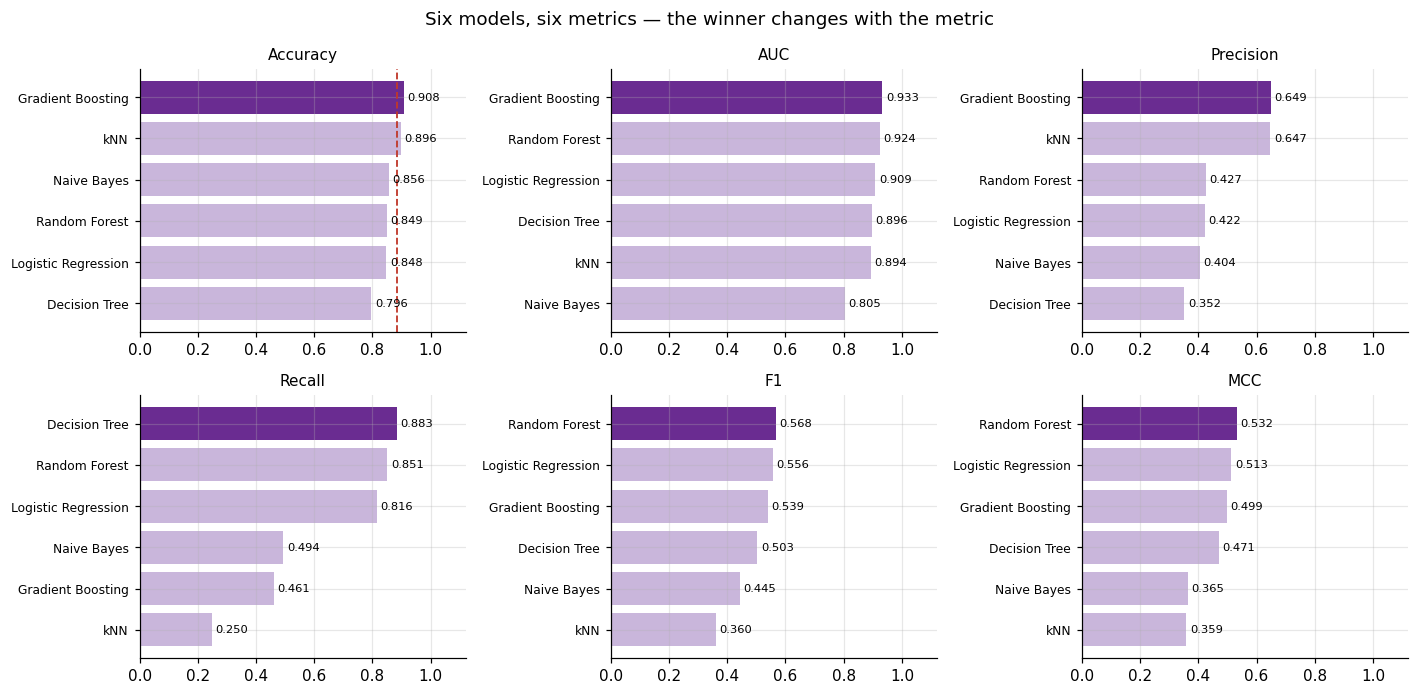

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.4))

for axis, metric in zip(axes.ravel(), METRICS):
    ordered = comparison[metric].sort_values()
    colours = [PURPLE if v == ordered.max() else LILAC for v in ordered]
    axis.barh(range(len(ordered)), ordered.values, color=colours)
    axis.set_yticks(range(len(ordered)))
    axis.set_yticklabels([n.replace(" (Ensemble)", "") for n in ordered.index],
                         fontsize=8)
    for i, v in enumerate(ordered.values):
        axis.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=7.5)
    axis.set_title(metric, fontsize=10)
    axis.set_xlim(0, 1.12)
    if metric == "Accuracy":
        axis.axvline(baseline, color="#C0392B", linestyle="--", linewidth=1.2)

plt.suptitle("Six models, six metrics — the winner changes with the metric",
             fontsize=12)
plt.tight_layout(); plt.show()

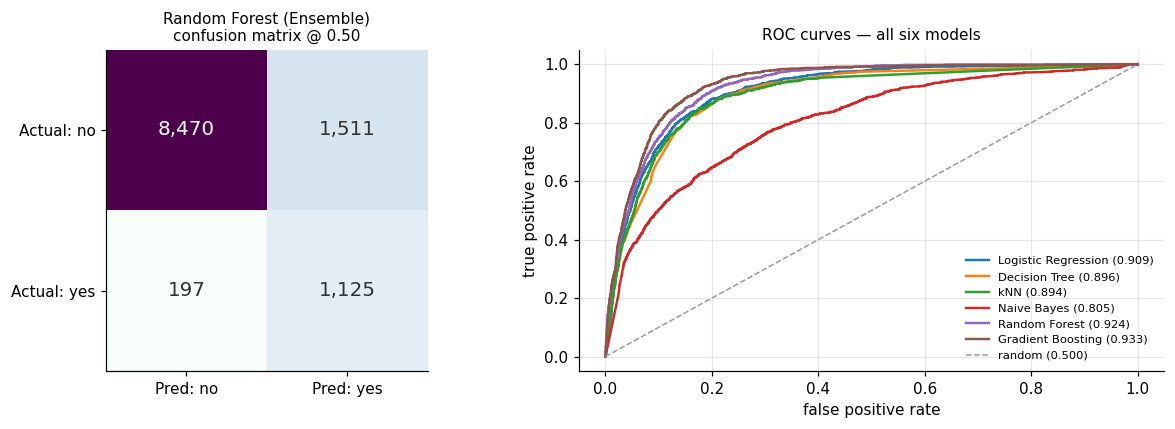

Random Forest (Ensemble):  TN=8,470  FP=1,511  FN=197  TP=1,125

                        precision    recall  f1-score   support

no (did not subscribe)       0.98      0.85      0.91      9981
      yes (subscribed)       0.43      0.85      0.57      1322

              accuracy                           0.85     11303
             macro avg       0.70      0.85      0.74     11303
          weighted avg       0.91      0.85      0.87     11303



In [10]:
champion = comparison["MCC"].idxmax()
predicted = fitted[champion].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

matrix = confusion_matrix(y_test, predicted, labels=[0, 1])
axes[0].imshow(matrix, cmap="BuPu")
for (r, c), v in np.ndenumerate(matrix):
    axes[0].text(c, r, f"{v:,}", ha="center", va="center", fontsize=13,
                 color="white" if v > matrix.max() / 2 else "#333")
axes[0].set_xticks([0, 1], ["Pred: no", "Pred: yes"])
axes[0].set_yticks([0, 1], ["Actual: no", "Actual: yes"])
axes[0].set_title(f"{champion}\nconfusion matrix @ 0.50", fontsize=10)
axes[0].grid(False)

for name, pipeline in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, linewidth=1.6,
                 label=f"{name.replace(' (Ensemble)','')} ({comparison.loc[name,'AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="#999", linewidth=1, label="random (0.500)")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curves — all six models", fontsize=10)
axes[1].legend(fontsize=7.5, loc="lower right", frameon=False)

plt.tight_layout(); plt.show()

tn, fp, fn, tp = matrix.ravel()
print(f"{champion}:  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}\n")
print(classification_report(y_test, predicted,
                            target_names=["no (did not subscribe)", "yes (subscribed)"],
                            zero_division=0))

## 7. Threshold sensitivity

0.50 is a **convention**, not a property of the data. Because kNN and Naive Bayes
cannot be class-weighted, a 0.50 cut-off on an 11.7%-positive problem penalises
them structurally. Sweeping the threshold separates *ranking ability* from
*calibration*.

In [11]:
sweep = []
for name, pipeline in fitted.items():
    probability = pipeline.predict_proba(X_test)[:, 1]
    for threshold in np.arange(0.05, 1.0, 0.05):
        sweep.append({
            "model": name, "threshold": round(float(threshold), 2),
            "MCC": matthews_corrcoef(y_test, (probability >= threshold).astype(int)),
        })
sweep = pd.DataFrame(sweep)

best = sweep.loc[sweep.groupby("model")["MCC"].idxmax()].set_index("model")
best["MCC @ 0.50"] = comparison["MCC"]
best["gain"] = best["MCC"] - best["MCC @ 0.50"]

print("Best achievable MCC per model, and the threshold that achieves it:\n")
print(best[["MCC @ 0.50", "MCC", "threshold", "gain"]]
      .sort_values("MCC", ascending=False).round(4).to_string())

tuned = best["MCC"].idxmax()
spread = comparison["AUC"].max() - comparison["AUC"].min()
print(f"\n  >> Threshold-tuned winner : {tuned} "
      f"(MCC {best.loc[tuned,'MCC']:.4f} @ {best.loc[tuned,'threshold']:.2f})")
print(f"  >> Largest gain from tuning: {best['gain'].idxmax()} "
      f"(+{best['gain'].max():.4f} MCC)")
print(f"  >> Best-to-worst AUC spread across all six models is only {spread:.4f}.")
print("  >> Tuning ONE model's threshold moved MCC further than the entire")
print("  >> algorithmic spread: the threshold matters more than the algorithm.")

Best achievable MCC per model, and the threshold that achieves it:

                              MCC @ 0.50     MCC  threshold    gain
model                                                              
Gradient Boosting (Ensemble)      0.4985  0.5838       0.25  0.0853
Random Forest (Ensemble)          0.5317  0.5463       0.65  0.0147
Logistic Regression               0.5130  0.5288       0.65  0.0157
kNN                               0.3586  0.5148       0.20  0.1563
Decision Tree                     0.4713  0.5036       0.65  0.0323
Naive Bayes                       0.3649  0.3688       0.70  0.0039

  >> Threshold-tuned winner : Gradient Boosting (Ensemble) (MCC 0.5838 @ 0.25)
  >> Largest gain from tuning: kNN (+0.1563 MCC)
  >> Best-to-worst AUC spread across all six models is only 0.1275.
  >> Tuning ONE model's threshold moved MCC further than the entire
  >> algorithmic spread: the threshold matters more than the algorithm.


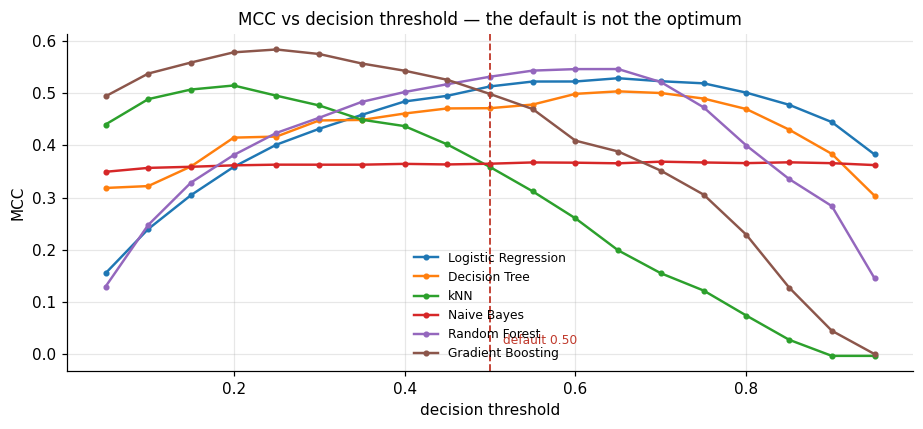

In [12]:
fig, axis = plt.subplots(figsize=(8.5, 4))
for name in fitted:
    subset = sweep[sweep["model"] == name]
    axis.plot(subset["threshold"], subset["MCC"], marker="o", markersize=3,
              linewidth=1.6, label=name.replace(" (Ensemble)", ""))
axis.axvline(0.50, color="#C0392B", linestyle="--", linewidth=1.2)
axis.text(0.515, 0.02, "default 0.50", color="#C0392B", fontsize=8)
axis.set_xlabel("decision threshold"); axis.set_ylabel("MCC")
axis.set_title("MCC vs decision threshold — the default is not the optimum",
               fontsize=11)
axis.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 8. Target leakage in `duration`

`duration` is the call length in seconds — known **only after the call ends**. A
model relying on it cannot decide whom to call. Retrained without it, the honest
performance ceiling is far lower.

In [13]:
leak_rows = []
for label, numeric in [("with duration", NUMERIC),
                       ("without duration", [c for c in NUMERIC if c != "duration"])]:
    for name, estimator in [
        ("Logistic Regression", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=SEED)),
        ("Random Forest", RandomForestClassifier(
            n_estimators=200, max_depth=14, min_samples_leaf=10,
            class_weight="balanced_subsample", random_state=SEED)),
    ]:
        pipeline = Pipeline([("encode", make_encoder(numeric=numeric)),
                             ("classify", estimator)])
        pipeline.fit(X_train, y_train)
        leak_rows.append({"model": name, "variant": label,
                          **score(pipeline, X_test, y_test)})

leak = pd.DataFrame(leak_rows).pivot(index="model", columns="variant")
for metric in ["AUC", "MCC"]:
    block = leak[metric].copy()
    block["drop"] = block["with duration"] - block["without duration"]
    print(f"--- {metric} ---"); print(block.round(4).to_string()); print()

forest = fitted["Random Forest (Ensemble)"]
names = [n.split("__", 1)[-1]
         for n in forest.named_steps["encode"].get_feature_names_out()]
importance = pd.Series(forest.named_steps["classify"].feature_importances_,
                       index=names).sort_values(ascending=False)
print("Random Forest — top 8 feature importances:")
print(importance.head(8).round(4).to_string())
print(f"\n  >> 'duration' alone is {importance['duration']:.1%} of total importance —")
print(f"  >> more than the other {len(names) - 1} encoded features combined.")
print("  >> Every headline number above is optimistic for a real pre-call model.")

--- AUC ---
variant              with duration  without duration    drop
model                                                       
Logistic Regression         0.9085            0.7731  0.1354
Random Forest               0.9239            0.7979  0.1260

--- MCC ---
variant              with duration  without duration    drop
model                                                       
Logistic Regression         0.5130            0.2883  0.2248
Random Forest               0.5317            0.3782  0.1535

Random Forest — top 8 feature importances:
duration                   0.4688
poutcome_success           0.0623
contact_unknown            0.0559
age                        0.0469
housing_yes                0.0403
balance                    0.0399
days_since_last_contact    0.0336
day                        0.0336

  >> 'duration' alone is 46.9% of total importance —
  >> more than the other 42 encoded features combined.
  >> Every headline number above is optimistic for a real pre-

## 9. Conclusion

| Finding | Evidence |
|---|---|
| Accuracy is misleading here | Baseline is 88.3%; two models score *below* it yet beat kNN on MCC |
| Random Forest is the best default | Top F1 and MCC at threshold 0.50 |
| Gradient Boosting is the strongest learner | Best AUC (threshold-independent) and best tuned MCC |
| kNN's weakness was calibration, not ranking | No `class_weight` support ⇒ collapses at 0.50, recovers sharply near 0.20 |
| Naive Bayes is genuinely weakest | Worst AUC; conditional-independence assumption structurally violated |
| Threshold choice > algorithm choice | Retuning one cut-off moved MCC more than the whole best-to-worst AUC spread |
| All results lean on a leaky feature | `duration` is ~47% of Random Forest importance and is unknown before a call |

**Overall winner: Gradient Boosting** on the evidence (best AUC, best tuned MCC),
with **Random Forest** the pragmatic default at the untuned 0.50 threshold.

---
*Executed on BITS Virtual Lab. Full project, deployed Streamlit app and README:*
*https://github.com/rgarg005/bits-ml-assignment-2*

In [14]:
print("=" * 74)
print("EXECUTION COMPLETE")
print("=" * 74)
print(f"  models trained : {len(fitted)}")
print(f"  metrics each   : {len(METRICS)}  ({', '.join(METRICS)})")
print(f"  test rows      : {len(X_test):,}")
print(f"  best by MCC    : {comparison['MCC'].idxmax()} "
      f"({comparison['MCC'].max():.4f})")
print(f"  best by AUC    : {comparison['AUC'].idxmax()} "
      f"({comparison['AUC'].max():.4f})")
print(f"  host / user    : {socket.gethostname()} / {getpass.getuser()}")
print(f"  finished       : {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 74)

EXECUTION COMPLETE
  models trained : 6
  metrics each   : 6  (Accuracy, AUC, Precision, Recall, F1, MCC)
  test rows      : 11,303
  best by MCC    : Random Forest (Ensemble) (0.5317)
  best by AUC    : Gradient Boosting (Ensemble) (0.9327)
  host / user    : macos-C413W3LDH7 / rgarg5
  finished       : 2026-08-17 16:58:24
